# Generación de Gráficos

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../resultados/resultados_tests.csv")
print(df["metodo"].unique())
print(df.shape)
potencia = (
    df.groupby(["escenario", "metodo"])["resultado"]
    .mean()
    .mul(100)
    .reset_index(name="porcentaje")
)

<StringArray>
[     't_student',       'wilcoxon', 'hodges_lehmann',     'perm_media',
   'perm_mediana',      'perm_trim']
Length: 6, dtype: str
(39000, 5)


## Potencia

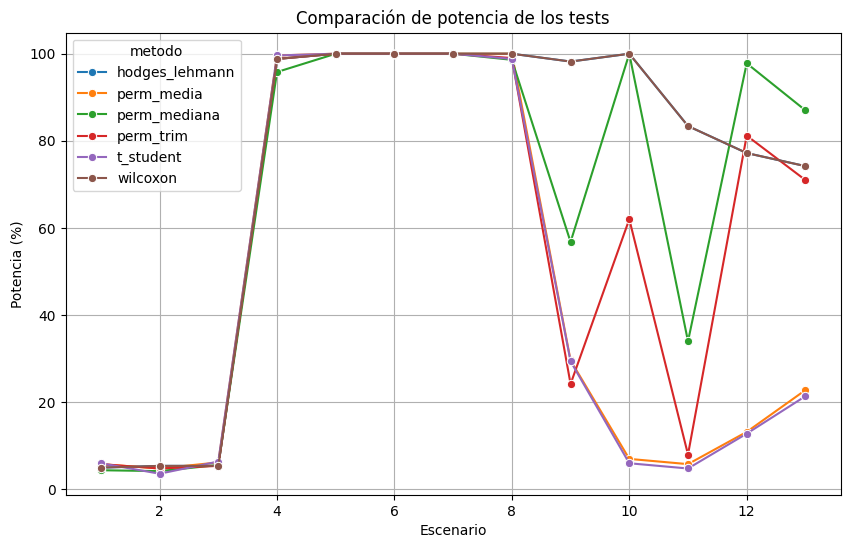

In [44]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=potencia,
    x="escenario",
    y="porcentaje",
    hue="metodo",
    marker="o"
)

plt.ylabel("Potencia (%)")
plt.xlabel("Escenario")
plt.title("Comparación de potencia de los tests")
plt.grid(True)

plt.show()

## Heatmap de rechazo

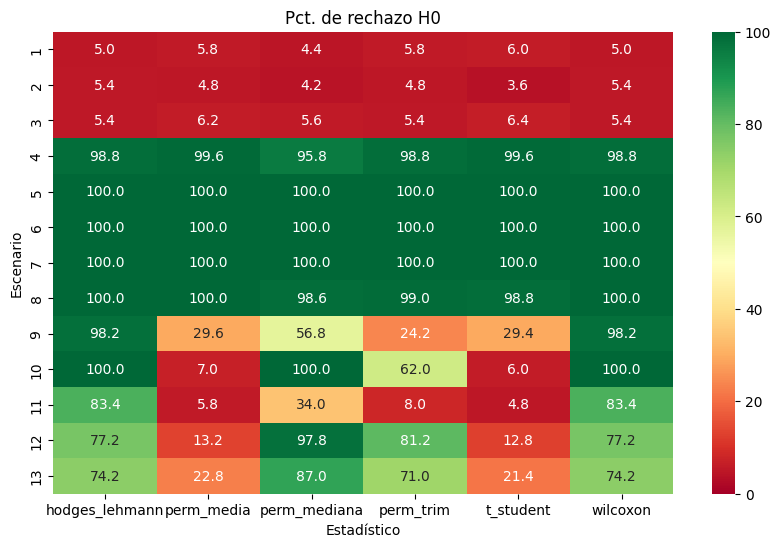

In [45]:
tabla = potencia.pivot(
    index="escenario",
    columns="metodo",
    values="porcentaje"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    tabla,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",   # rojo → amarillo → verde
    vmin=0,
    vmax=100
)

plt.title("Pct. de rechazo H0")
plt.xlabel("Estadístico")
plt.ylabel("Escenario")

plt.show()

## Comparación de Potencia

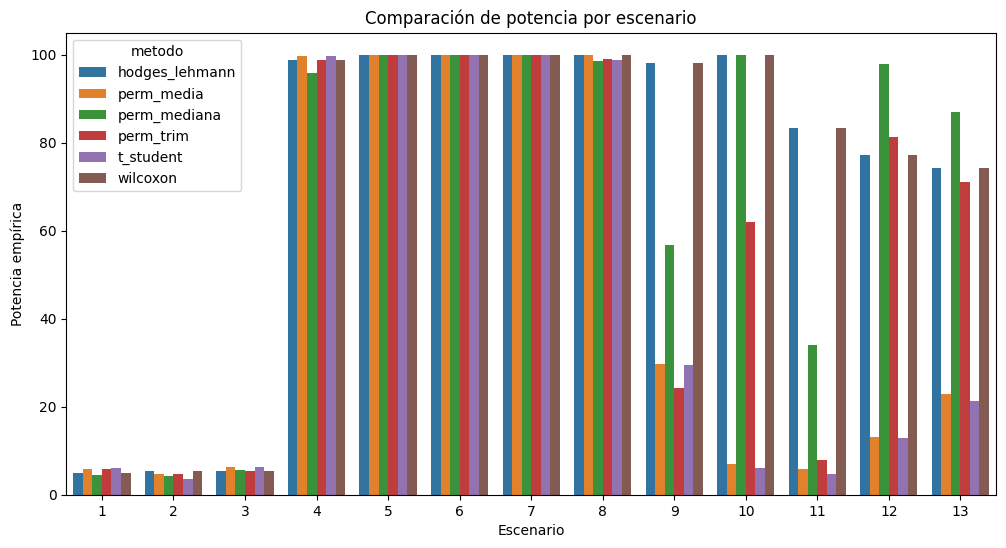

In [46]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=potencia,
    x="escenario",
    y="porcentaje",
    hue="metodo"
)

plt.ylabel("Potencia empírica")
plt.xlabel("Escenario")
plt.title("Comparación de potencia por escenario")

plt.show()

In [47]:
df["metodo"].unique()

<StringArray>
[     't_student',       'wilcoxon', 'hodges_lehmann',     'perm_media',
   'perm_mediana',      'perm_trim']
Length: 6, dtype: str

# Tiempo de Ejecución

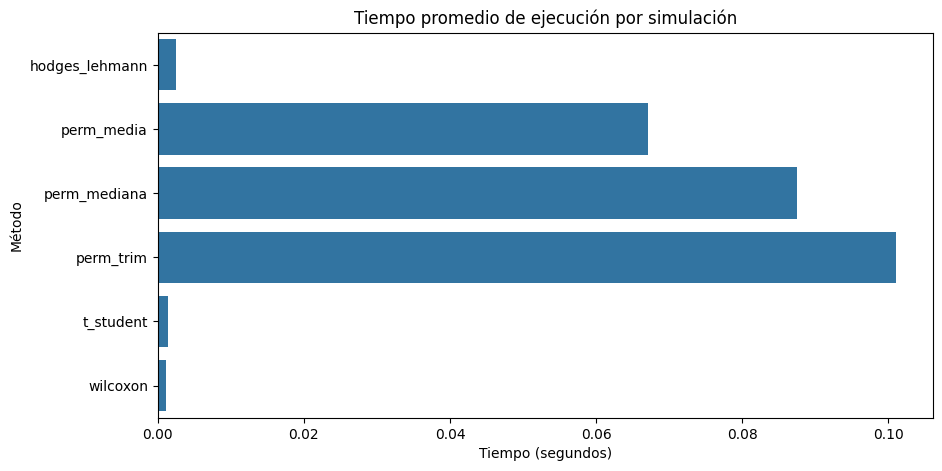

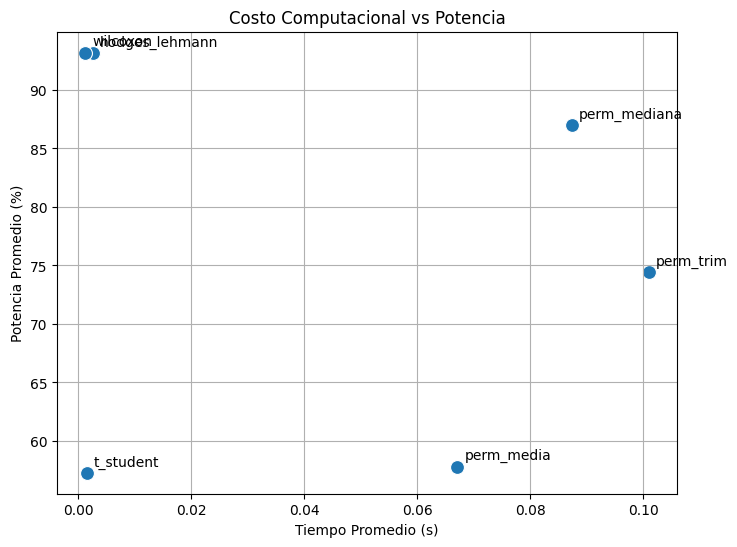

In [48]:
# Gráfico de barras de tiempo de ejecución
tiempos = df.groupby('metodo')['tiempo'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=tiempos, x='tiempo', y='metodo', orient='h')
plt.title('Tiempo promedio de ejecución por simulación')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Método')
plt.show()

# Gráfico Costo-Beneficio (Potencia excluyendo casos nulos 1, 2, 3 vs Tiempo)
potencia_real = df[~df['escenario'].isin([1, 2, 3])].groupby('metodo')['resultado'].mean() * 100
resumen = pd.DataFrame({
    'Potencia Promedio (%)': potencia_real,
    'Tiempo Promedio (s)': tiempos.set_index('metodo')['tiempo']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=resumen, x='Tiempo Promedio (s)', y='Potencia Promedio (%)', s=100)

for i, txt in enumerate(resumen.index):
    plt.annotate(txt, (resumen['Tiempo Promedio (s)'].iloc[i], resumen['Potencia Promedio (%)'].iloc[i]),
                 xytext=(5, 5), textcoords='offset points')

plt.title('Costo Computacional vs Potencia')
plt.grid(True)
plt.show()